# DATA SCI 185 Lab:
## Pandas vs. Polars and Matplotlib vs. Seaborn

<font size = "3">

- For certain applications you may want to use packages that don't come with the base Anaconda environment automatically.

- You can add additional packages to the base environment, but
    - Some packages can be incompatible with each other
    - For organization, you may want to create separate environments for each application/project you work on.

- Today we will create a new Anaconda environment and use two packages that are not automatically included in the base environment:

    1. `polars` is a "high-performance" alternative to `pandas` (it can be faster than `pandas` for large data sets)
    2. `seaborn` is a visualization library that is based on `matplotlib`. It makes plots/figures that are more visually pleasing.

## 1. Set Up Your Anaconda Environment

For this lab, we will use the **Anaconda Navigator application** to create a separate environment for this class and install the packages there.

### Step 1: Open Anaconda Navigator
1. Open the **Anaconda Navigator** application.
2. In the left sidebar, click **Environments**.

<img src="images/conda_1.png" alt="drawing" width="450"/>


### Step 2: Create a New Environment
1. Click **Create** at the bottom of the Environments page.

<img src="images/conda_2.png" alt="drawing" width="450"/>

2. Give your environment the name `lab02`.
3. Select a Python version available in Anaconda Navigator.

<img src="images/conda_3.png" alt="drawing" width="450"/>

4. Click **Create** and wait for the environment to finish setting up.

### Step 3: Install the Packages
1. Make sure your new `datasci185` environment is selected.
2. Change the package filter from **Installed** to **Not installed** or **All**.
3. Search for and select the following packages:
   - `pandas`
   - `polars`
   - `matplotlib`
   - `seaborn`
4. Click **Apply**.

<img src="images/conda_4.png" alt="drawing" width="650"/>

5. Review the packages Anaconda will install, then click **Apply** again.


## 2. Import the Libraries

- Choose "Select Kernel", and select the environment you just created.

- If your Anaconda environment was set up correctly, the imports below should run without an error.

- If you use the base environment instead, the two of the imports will fail (unless you add the packages to base)


In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Reading Data from a CSV File

For today's lab, we will use `student_data.csv` stored in the `data` subfolder.

Each row represents a student and includes:

- `name`
- `major`
- `year` (1 = freshman, 2 = sophomore, etc.)
- `study_hours`
- `exam_score`
- `attendance`

### Reading a CSV with Pandas

You have already worked with Pandas, so let's first use `pd.read_csv()` to load the file. 

We can display the whole dataset, or just the first 5 rows using `.head()`


In [11]:
pandas_df = pd.read_csv("data/student_data.csv")

pandas_df.head()

,name,major,year,study_hours,exam_score,attendance
0,Ava,CS,1,5,82,90
1,Ben,Biology,2,3,74,80
2,Cam,CS,3,8,94,98
3,Dani,Math,2,6,88,92
4,Eli,Biology,4,2,68,75


### Your Turn: Read the Same CSV with Polars

Polars has its own function for reading CSV files.

Use the Polars documentation or what you know about the Pandas command above to figure out how to load in `student_data.csv` using polars. Name the variable `polars_df`.

Then display the first five rows of the dataset.

**Hint:** The code is *very* similar to the one for pandas.

In [12]:
# Read student_data.csv using Polars
# YOUR CODE HERE
polars_df = pl.read_csv("data/student_data.csv")

polars_df.head()



name,major,year,study_hours,exam_score,attendance
str,str,i64,i64,i64,i64
"""Ava""","""CS""",1,5,82,90
"""Ben""","""Biology""",2,3,74,80
"""Cam""","""CS""",3,8,94,98
"""Dani""","""Math""",2,6,88,92
"""Eli""","""Biology""",4,2,68,75


Single variables/columns can be accessed in the same way - the output just looks a little different

In [13]:
pandas_df['year']

0    1
1    2
2    3
3    2
4    4
5    1
6    3
7    4
8    2
9    3
Name: year, dtype: int64

In [14]:
polars_df['year']

year
i64
1
2
3
2
4
1
3
4
2


### Compare the basic information

In Pandas we can get more information about the datset using `.shape` and `.columns`. Polars provides similar information.


In [15]:
print("Pandas shape:", pandas_df.shape)
print("Pandas columns:", pandas_df.columns)

print("\nPolars shape:", polars_df.shape)
print("Polars columns:", polars_df.columns)

Pandas shape: (10, 6)
Pandas columns: Index(['name', 'major', 'year', 'study_hours', 'exam_score', 'attendance'], dtype='str')

Polars shape: (10, 6)
Polars columns: ['name', 'major', 'year', 'study_hours', 'exam_score', 'attendance']


### **Exercise**: Summary Statistics

In Lecture 1, we used `.describe()` to calculate basic summary statistics in pandas.

In [16]:
pandas_df.describe()

,year,study_hours,exam_score,attendance
count,10.000000,10.000000,10.000000,10.000000
mean,2.500000,5.500000,84.800000,89.500000
std,1.080123,2.173067,9.126275,7.763876
min,1.000000,2.000000,68.000000,75.000000
25%,2.000000,4.250000,79.750000,85.250000
50%,2.500000,5.500000,86.500000,91.000000
75%,3.000000,6.750000,90.750000,94.500000
max,4.000000,9.000000,97.000000,99.000000


Try the equivalent operation using your Polars DataFrame. Compare the output to Pandas.

After running both versions, think about:
- Do they report the same types of summary statistics?
- Is the output formatted the same way?

In [17]:
# Use Polars to calculate summary statistics
# YOUR CODE HERE
polars_df.describe([0.33, 0.66])

statistic,name,major,year,study_hours,exam_score,attendance
str,str,str,f64,f64,f64,f64
"""count""","""10""","""10""",10.0,10.0,10.0,10.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",null,null,2.5,5.5,84.8,89.5
"""std""",null,null,1.080123,2.173067,9.126275,7.763876
"""min""","""Ava""","""Biology""",1.0,2.0,68.0,75.0
"""33%""",null,null,2.0,5.0,82.0,89.0
"""66%""",null,null,3.0,6.0,90.0,93.0
"""max""","""Jada""","""Math""",4.0,9.0,97.0,99.0


**Q**: How should we change `.describe()` code so that it prints out the 33% and 66% percentile, instead of 25%, 50%, and 75%? 

**Hint:** See Lecture01.ipynb or type `help(polars_df.describe)`

In [ ]:
# YOUR CODE HERE


---

# Part II: Matplotlib vs. Seaborn

Matplotlib and Seaborn both create visualizations, but they serve slightly different roles.

- **Matplotlib** gives you detailed, lower-level control over a plot.
- **Seaborn** is built on Matplotlib and provides a higher-level interface for many statistical visualizations.

We will use the Pandas DataFrame for plotting because Seaborn works naturally with Pandas DataFrames.


## 4. Scatter Plot

Let's look at the relationship between **study hours** and **exam score**.

### Matplotlib

Here, we just create a scatter plot of study hours vs. exam score and use `plt.show()`

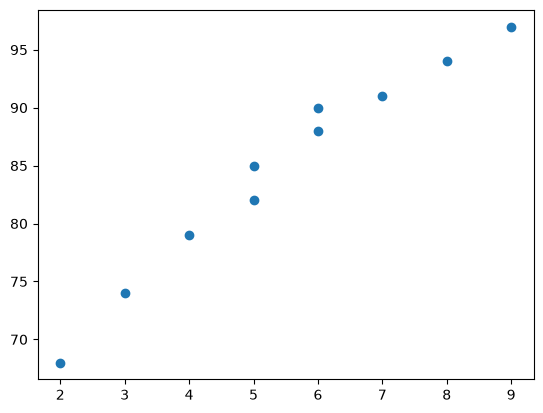

In [18]:
plt.scatter(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.show()

### Seaborn

We do the same in Seaborn. Note that we still use `plt.show()`. What is different so far?


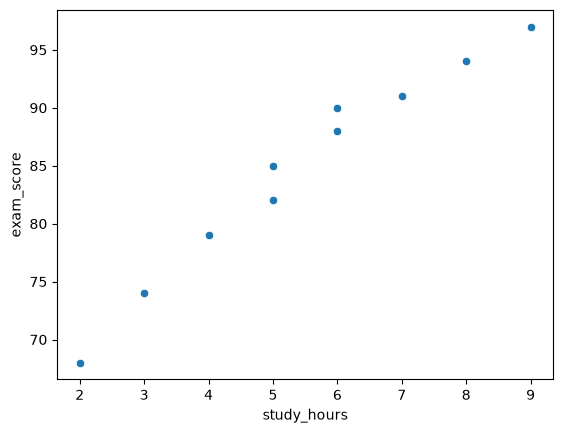

In [19]:
sns.scatterplot(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.show() 

<font size = "4">

We can label the axes in matplotlib and add a title:

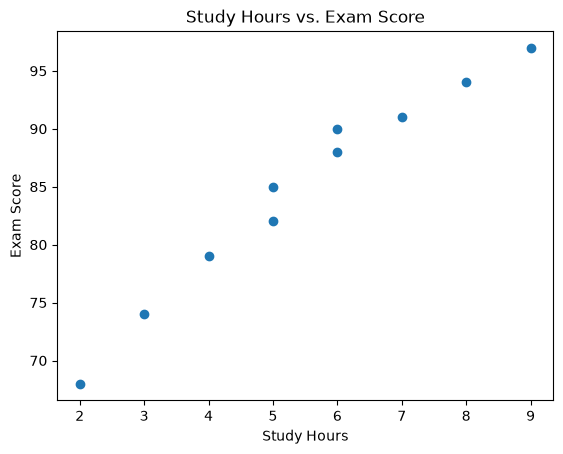

In [20]:
plt.scatter(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.show()

<font size = "4">

For presentation purposes, the axis labels "study_hours" and "exam_score" are an eyesore. How can we add our own labels to the seaborn plot? Add a title as well.

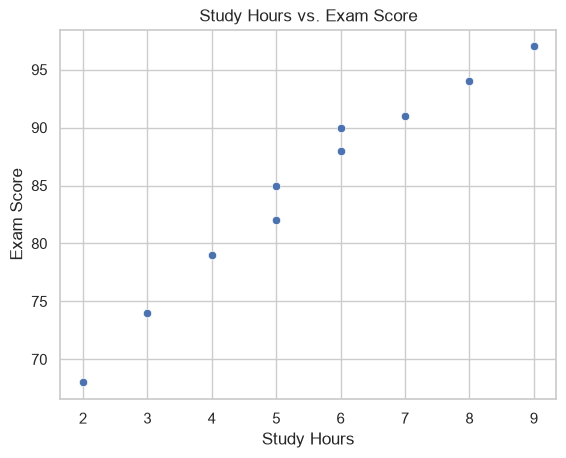

In [22]:
sns.scatterplot(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.ylabel("Exam Score")
plt.xlabel("Study Hours")
plt.title("Study Hours vs. Exam Score")
### Replace the x-axis and y-axis labels so no underscores are present
### Add a title


plt.show() 

## 5. Seaborn Gallery

<font size = "4">

The following examples demonstrate how seaborn can make more visually appealing plots.

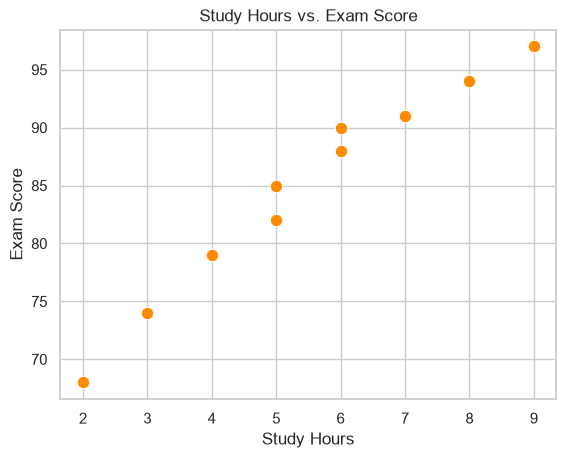

In [21]:
sns.set_theme(style="whitegrid")

# s = 80 sets the point size
sns.scatterplot(x=pandas_df["study_hours"], y=pandas_df["exam_score"], s=80, color="darkorange")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.show()

<font size = "4">

Some color options you can try besides "darkorange"

- "mediumorchid"
- "steelblue"
- "crimson"
- "forestgreen"
- "teal"
- "coral"
- "deeppink"

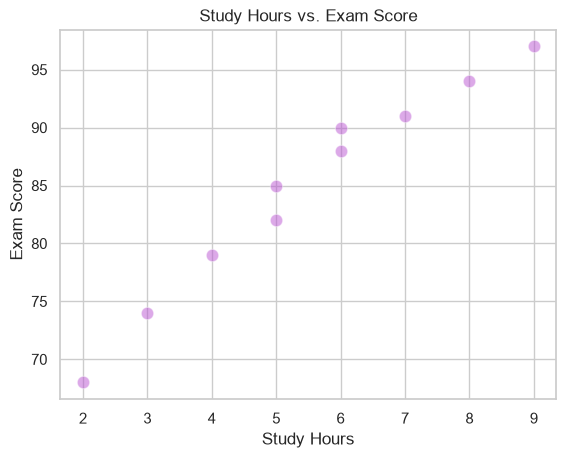

In [23]:
sns.set_theme(style="whitegrid")

# alpha = 0.5 sets the transparency of the dots
#   alpha = 1.0 is opaque
#   alpha = 0.0 is completely transparent (invisible)
sns.scatterplot(x=pandas_df["study_hours"], y=pandas_df["exam_score"], s=80, color="mediumorchid",alpha=0.5)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.show()

<font size = "4">

You can add a linear regression to a scatter plot quite easily in seaborn.

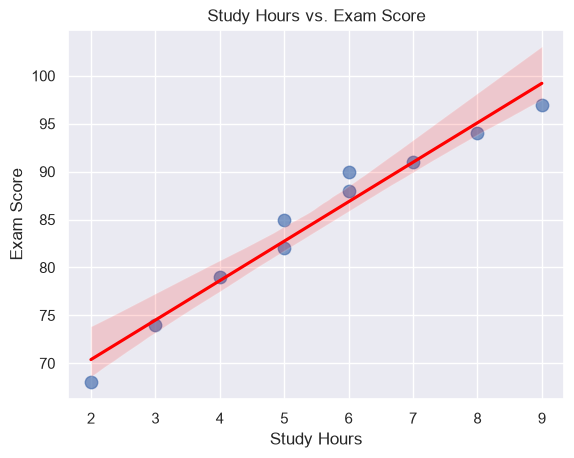

In [24]:
sns.set_theme(style = "darkgrid") # change theme from whitegrid to darkgrid

# scatter_kws - "keywords" for the scatter plot
# line_kws - "keywords" for the line plot
# ci - confidence interval. We can set it to 95%

sns.regplot(data=pandas_df, x="study_hours", y="exam_score", scatter_kws={"s": 80, "alpha": 0.7},line_kws={"color": "red"}, ci=95)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.show()

<font size = "4">

We can change the overall color palette as well. Run the next cell with different palette options.

In [ ]:
sns.set_theme(style="darkgrid")
sns.set_palette("Set2")
# sns.set_palette("deep") # default-ish Seaborn colors
# sns.set_palette("muted") # softer colors
# sns.set_palette("bright") # vivid colors
# sns.set_palette("pastel") # lighter colors
# sns.set_palette("dark") # darker colors
# sns.set_palette("colorblind")# colorblind-friendly

sns.scatterplot(data=pandas_df, x="study_hours", y="exam_score",s=100)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.show()

<font size = "4">

We can give different colors for each grade level (represented in the "year" variable)

In [ ]:
sns.set_theme(style="whitegrid")

sns.scatterplot(data=pandas_df, x="study_hours", y="exam_score", hue="year",s=80)

plt.title("Study Hours vs. Exam Score")
plt.show()